In [2]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

from pathlib import Path

base = Path.cwd()                   
Ausgabe_path = Path(base/"Diagramme")
print(Ausgabe_path)

c:\Users\samue\OneDrive\Dokumente\FP01\Diagramme


In [3]:
def fit_func(f,V,W1,W2,n1,n2):
    f_safe = np.clip(np.abs(f), 1e-12, None)
    return V/(np.sqrt(1+1/(f/W1)**(2*n1))*np.sqrt(1+(f/W2)**(2*n2)))
def fit_func2(f,V,W1,n1):
    f_safe = np.clip(np.abs(f), 1e-12, None)
    return V / np.sqrt(1 + 1 / (f_safe / W1) ** (2 * n1))


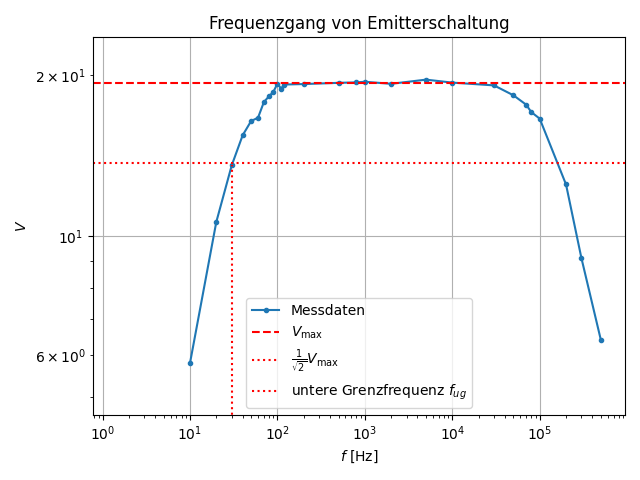

In [4]:
plt.close('all')
plt.figure()
plt.title(r'Frequenzgang von Emitterschaltung')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$V$')
f=np.concatenate((np.array([10,20,30,40,50,60,70,80,90,100,110,120,200,500,800]),np.array([1,2,5,10,30,50,70,80,100,200,300,500])*1e3))
V=np.array([5.79,10.64,13.57,15.45,16.43,16.67,17.83,18.28,18.64,19.31,18.90,19.23,19.27,19.37,19.41,19.46,19.29,19.64,19.39,19.16,18.36,17.63,17.08,16.60,12.5,9.1,6.4])
# D=1e-3
# g=P/D
plt.loglog(f,V,marker='.',label=rf'Messdaten')
plt.axhline(np.mean(V[11:19]),color='red',linestyle='dashed',label=r'$V_\text{max}$')
plt.axhline(1/np.sqrt(2)*np.mean(V[11:19]),color='red',linestyle='dotted',label=r'$\frac{1}{\sqrt{2}}V_\text{max}$')
plt.vlines(x=f[2],ymin=0,ymax=V[2],color='red',linestyle='dotted',label=r'untere Grenzfrequenz $f_{ug}$')
# plt.vlines(x=37.4,ymin=0,ymax=V[3],color='red',linestyle='dotted',label=r'$theoretische Grenzfrequenz$')

plt.ylim(np.min(V)*0.8,np.max(V)*1.2)
# def fit_func(f,V,W1,W2,n1,n2):
    # return V/(np.sqrt(1+1/(f/W1)**(2*n1))*np.sqrt(1+(f/W2)**(2*n2)))
# p0 = [1000 , 1000 , 50000 , 5 , 5]
# popt, pcov = curve_fit(fit_func, f, g ,p0)
# plt.loglog(f, fit_func(f, *popt), label='Fit')
# for i in range(len(p0)):
    # wert,fehler,latex,_=round_to_sigs(popt[i],np.sqrt(pcov[i][i]),einheiten='')
    # print(latex)
    # print(fehler/wert*100)
plt.legend()    
plt.grid()
plt.tight_layout()
plt.show()

In [5]:
popt, pcov = curve_fit(fit_func, f, V ,p0=[20, 10000, 100000, 1, 1])

C:\Users\samue\AppData\Local\Temp\ipykernel_7396\2784924508.py:3: RuntimeWarning: invalid value encountered in power
  return V/(np.sqrt(1+1/(f/W1)**(2*n1))*np.sqrt(1+(f/W2)**(2*n2)))


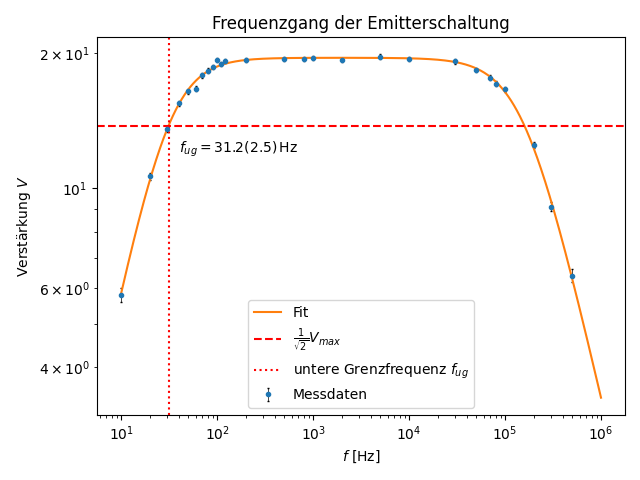

In [30]:

x=np.logspace(1, 6, 1000)
plt.figure()
plt.title(r'Frequenzgang der Emitterschaltung')
plt.errorbar(f,V,yerr=0.21,fmt='.',elinewidth=0.5,capsize=1,ecolor='black',label=rf'Messdaten')
plt.plot(x, fit_func(x, *popt), label='Fit')
plt.axhline(np.max(fit_func(x, *popt))/np.sqrt(2), label=r'$\frac{1}{\sqrt{2}}V_{max}$', color='red',linestyle='dashed')
plt.axvline(x=31.2, color='red', linestyle='dotted',label='untere Grenzfrequenz $f_{ug}$')
plt.text(4e1, 12, r'$f_{ug}=31.2(2.5) \, \text{Hz}$', color='black')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'Verstärkung $V$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(Ausgabe_path/"Frequenzgang_Fit_Emitterschaltung.png",format="png",bbox_inches='tight')

In [7]:
print(popt)

[1.95208965e+01 3.12147767e+01 1.58777660e+05 1.01705688e+00
 9.36958459e-01]


Frequenzgang Kollektorschaltung

In [8]:
f_col=np.array([10,30,50,70,100,500,2000,5000,10000,30000,50000,70000,100000,300000,500000]) #Hz
V_col=np.array([0.2, 0.7, 0.9, 0.9, 0.9, 0.96, 0.94, 0.99, 0.95, 1.02, 0.99, 1.13, 0.95, 0.95, 0.96]) #Verstärkung
V_col_f=np.concatenate((np.full(5, 0.5), np.full(10, 0.10))) #Fehler

In [9]:
popt1, pcov1= curve_fit(fit_func2, f_col, V_col, sigma=V_col_f, absolute_sigma=True, p0=[1, 10000, 1])
x2=np.logspace(1, 6, 1000)

C:\Users\samue\AppData\Local\Temp\ipykernel_7396\2784924508.py:6: RuntimeWarning: invalid value encountered in power
  return V / np.sqrt(1 + 1 / (f_safe / W1) ** (2 * n1))


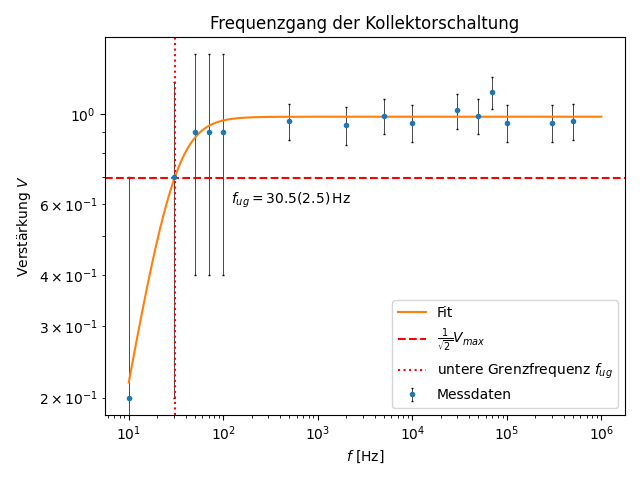

In [31]:
plt.figure()
plt.title(r'Frequenzgang der Kollektorschaltung')
plt.errorbar(f_col, V_col, yerr=V_col_f, fmt='.',elinewidth=0.5,capsize=1,ecolor='black', label=rf'Messdaten')
plt.plot(x2, fit_func2(x2, *popt1), label='Fit')
plt.axhline(np.max(fit_func2(x2, *popt1))/np.sqrt(2), label=r'$\frac{1}{\sqrt{2}}V_{max}$', color='red',linestyle='dashed')
plt.axvline(30.5, color='red', linestyle='dotted',label='untere Grenzfrequenz $f_{ug}$')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'Verstärkung $V$')
plt.text(1.2e2, 6e-1, r'$f_{ug}=30.5(2.5) \, \text{Hz}$')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.legend()
plt.savefig(Ausgabe_path/"Frequenzgang_Fit_Kollektorschaltung.png",format="png",bbox_inches='tight')